In [77]:
%load_ext autoreload
# %reload_ext autoreload
%autoreload 1

%aimport b6_epilepsies 
import b6_epilepsies as b6 #.py file in the same dir as this .ipynb
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# from scipy.stats import mannwhitneyu

# Define the custom color palette and genotype order
# new_colors_order = sns.color_palette(palette='Set2', n_colors=3)
# new_colors_order[0], new_colors_order[1], new_colors_order[2] = new_colors_order[1], new_colors_order[0], new_colors_order[2]
# color_map = dict(zip(['wt', 'het', 'hom'], new_colors_order))

#Middur output NOT FOR Sleep Analysis
# Define input variables
date   = "241107"
box1   = "16"
box2   = "17"
exp    = "PNPO_PTZ"
export = False
    
pnpo_ptz_obj_raw = b6.RawData(date, box1, box2, exp, export) #.prepped_data attribute to access df
# pnpo_ptz_obj_mid = b6.MiddurData(date, box1, box2, exp, export) #.prepped_data attribute to access df

df_raw = pnpo_ptz_obj_raw.df

# df_mid = pnpo_ptz_obj_mid.prepped_data


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Initialising RawData...
Start of experiment: 2024-07-11 16:25:58
Preparing data from 241107_16_17_PNPO_PTZ/241107_16_17_PNPO_PTZ_raw_df.csv.
We have a condition!
Dropping unecessary columns and duplicates...
Saved prepped df to 241107_16_17_PNPO_PTZ/241107_16_17_PNPO_PTZ_processed.csv
Done


/Users/jadelau/Development/Neuroscience/B6 Epilepsies/b6_epilepsies.py:507: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.
  sns.lineplot(ax=axes[0], x='elapsed_time', y='data1', data=fish_data, hue=hue, palette=palette)


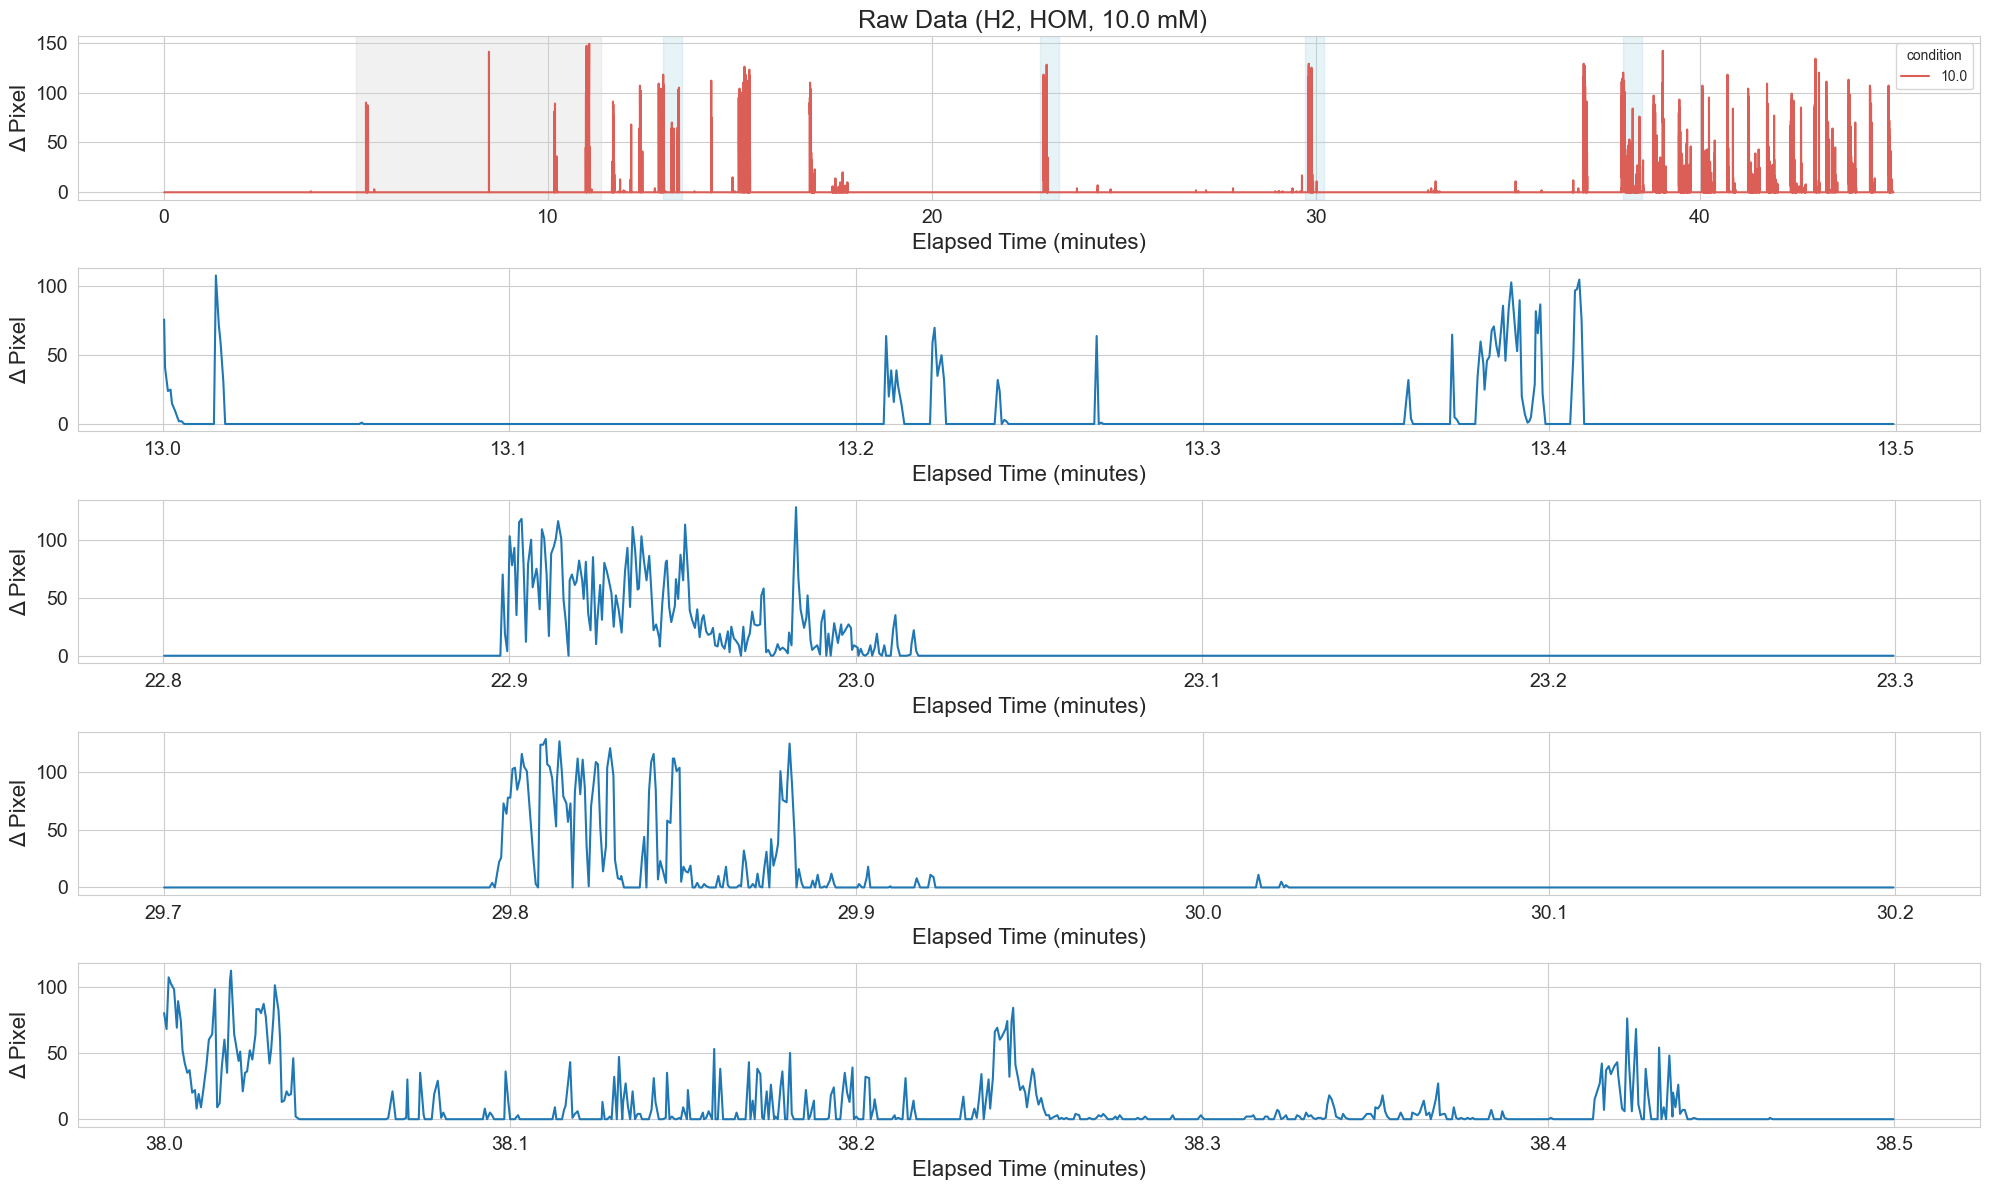

In [21]:
pnpo_ptz_obj_raw.plot_single_fish_activity(well='H2', event_windows=[
    (13, 13.5, "Seizure Event, Example 1"),
    (22.8, 23.3, "Seizure Event, Example 2"),
    (29.7, 30.2, "Seizure Event, Example 3"),
    (38, 38.5, "Normal Swimming Period, Example 4")
], drug_app=[5, 11.37], filterY=150, hue='condition')

/Users/jadelau/Development/Neuroscience/B6 Epilepsies/b6_epilepsies.py:507: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.
  sns.lineplot(ax=axes[0], x='elapsed_time', y='data1', data=fish_data, hue=hue, palette=palette)


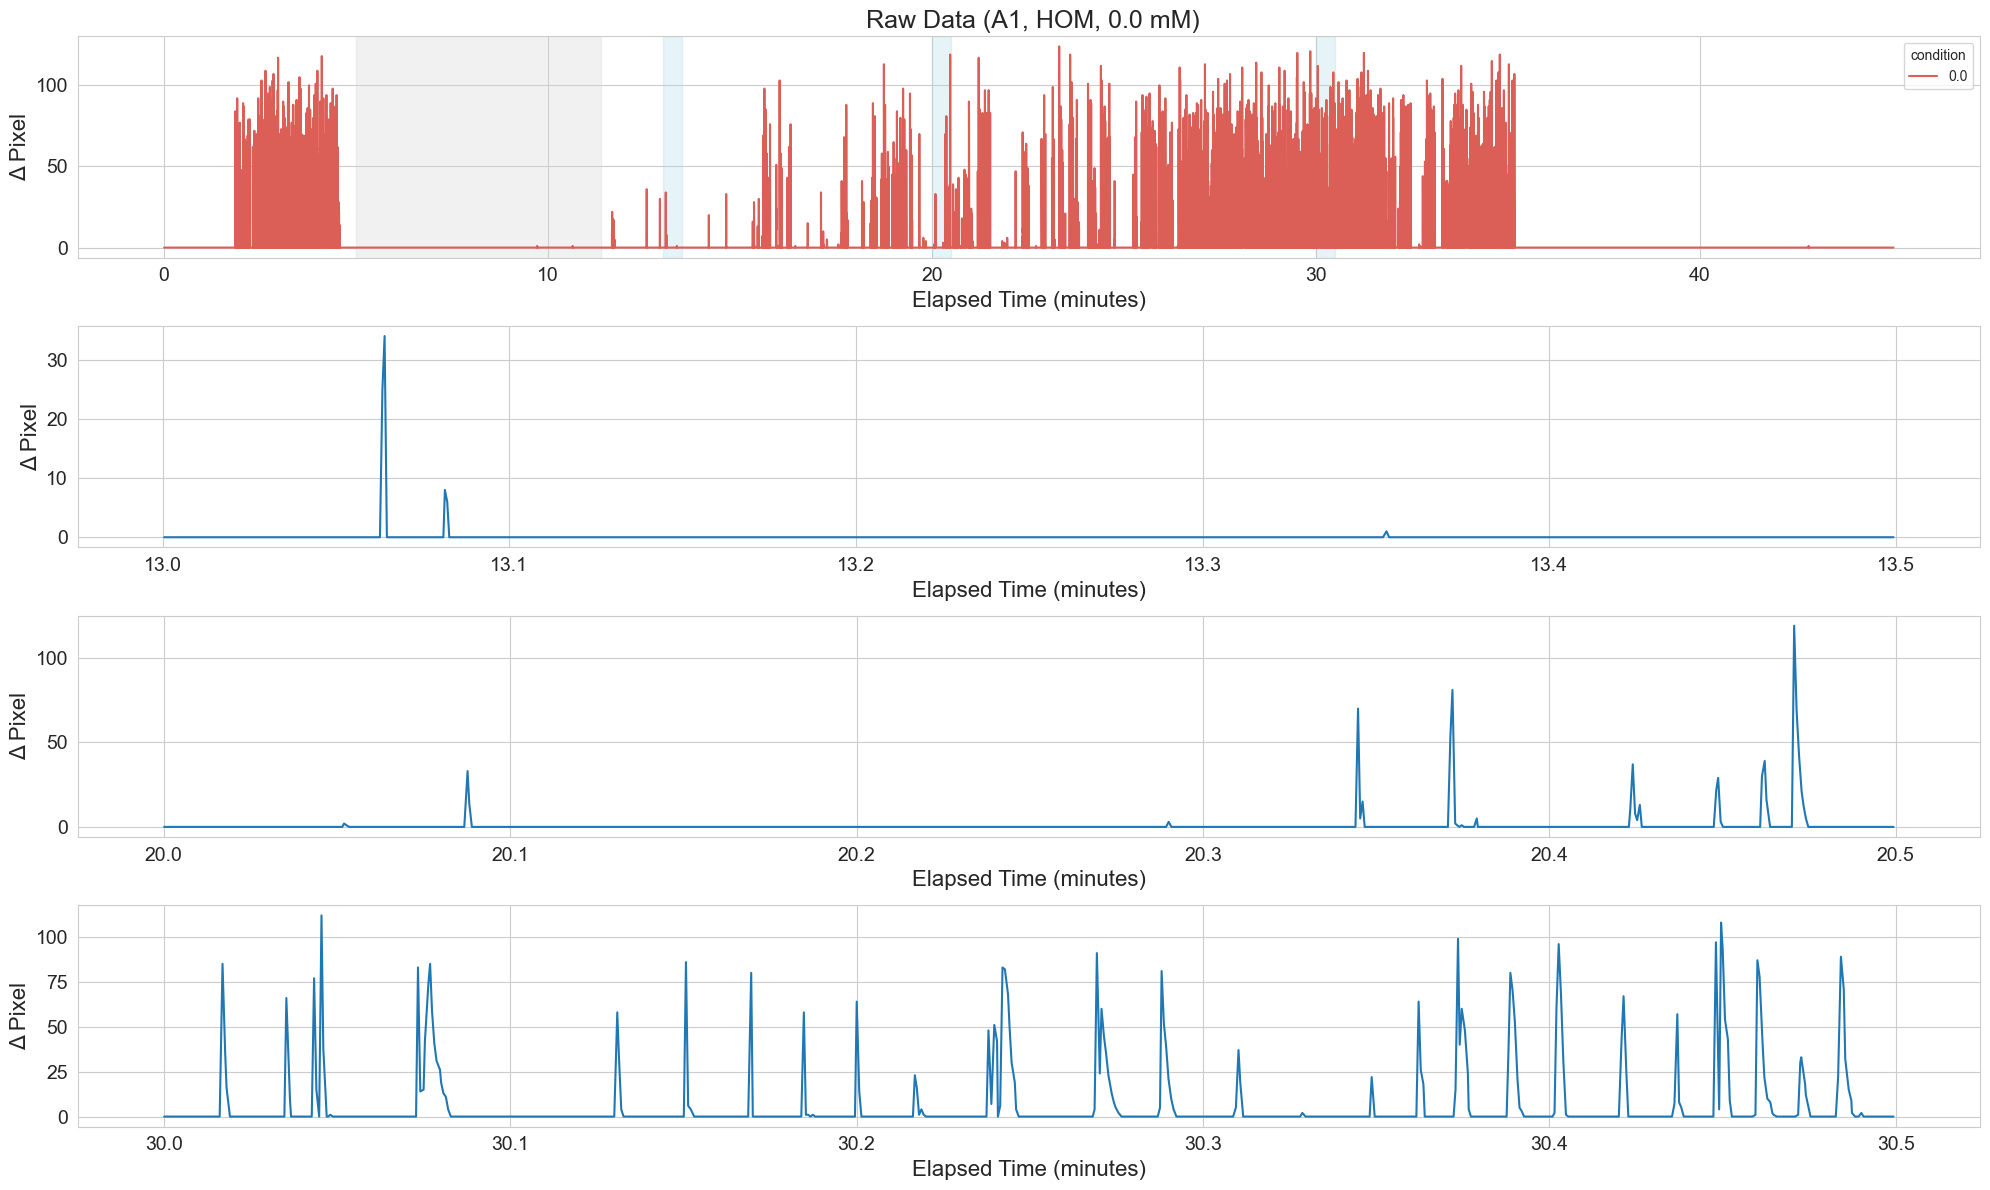

In [23]:
pnpo_ptz_obj_raw.plot_single_fish_activity(well='A1', event_windows=[
    (13, 13.5, "Normal Swimming, Example 1"),
    (20, 20.5, "Normal Swimming, Example 2"),
    (30, 30.5, "Normal Swimming, Example 3")
], drug_app=[5, 11.37], filterY=150, hue='condition')

/var/folders/99/9p1rqw911_b36bj9w7ly35q80000gn/T/ipykernel_19446/3744833959.py:43: UserWarning: The palette list has more values (8) than needed (1), which may not be intended.
  sns.lineplot(


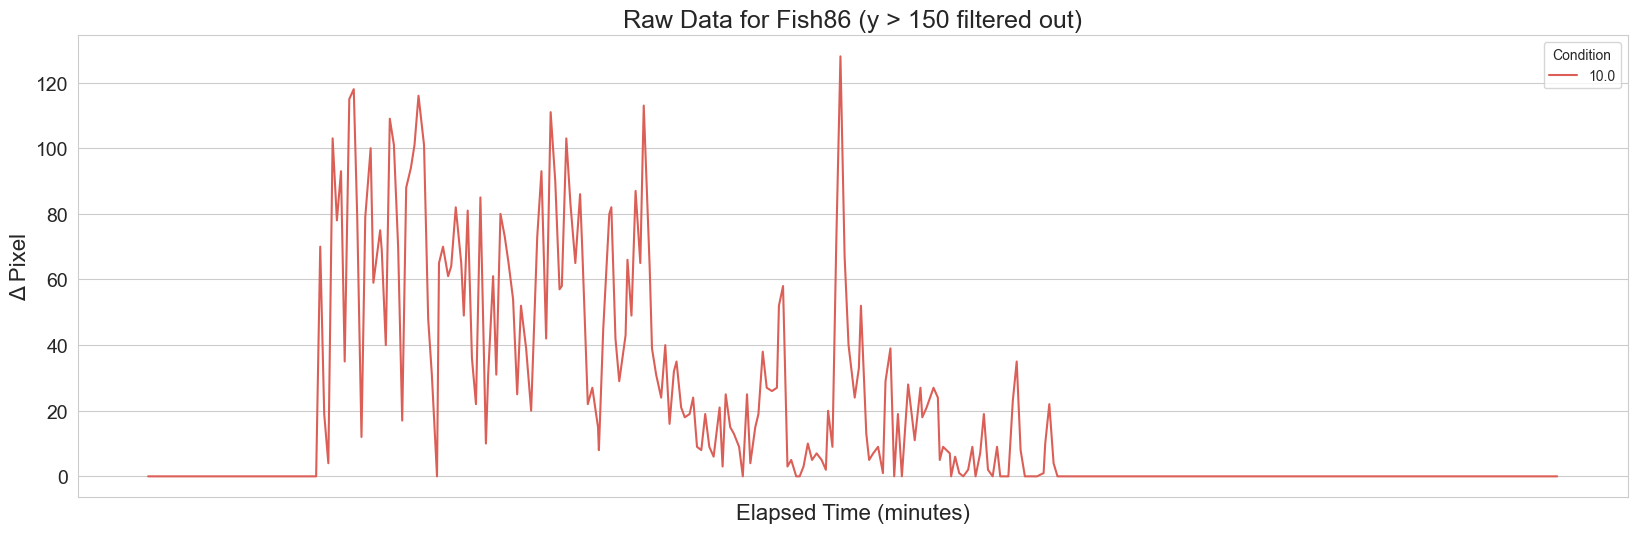

/var/folders/99/9p1rqw911_b36bj9w7ly35q80000gn/T/ipykernel_19446/3744833959.py:72: UserWarning: The palette list has more values (8) than needed (1), which may not be intended.
  sns.lineplot(


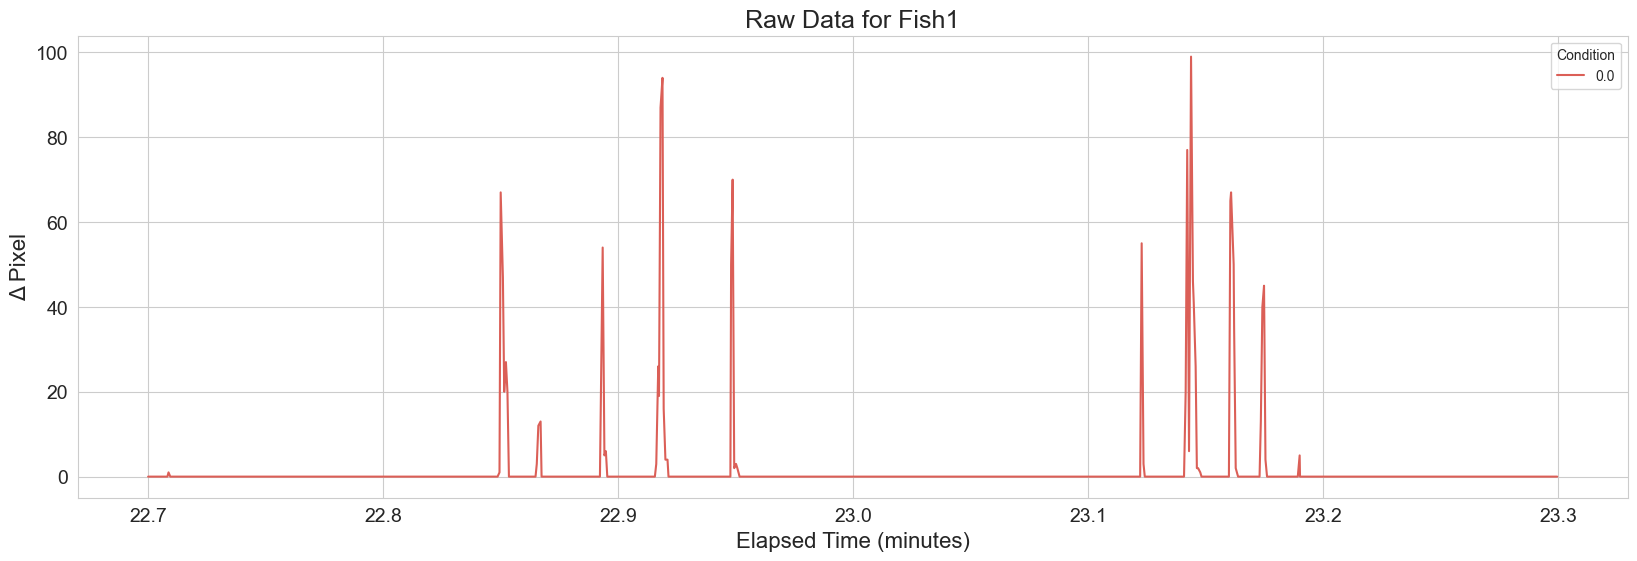

In [25]:
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import AutoMinorLocator

# Set the reference time (e.g., the earliest timestamp)
# Calculate elapsed time in seconds (or use .total_seconds() for float)
reference_time = df_raw['fullts'].min()
df_raw['elapsed_time'] = (df_raw['fullts'] - reference_time).dt.total_seconds()/60

# df_raw_22_24 = df_raw[(df_raw['elapsed_time'] >22) & (df_raw['elapsed_time'] <25) ]

# Set the reference time (e.g., the earliest timestamp)
# Calculate elapsed time in seconds (or use .total_seconds() for float)
# reference_time_mid = df_mid['stdate_sttime'].min()
# df_mid['elapsed_time'] = (df_mid['stdate_sttime'] - reference_time_mid).dt.total_seconds()/60

# df_mid_22_24 = df_mid[(df_mid['elapsed_time'] >22) & (df_mid['elapsed_time'] <25) ]

# exclude data1 more than 200


fish1     = df_raw[(df_raw['location'] == 'C001') & (df_raw['elapsed_time'] >22.7) & (df_raw['elapsed_time'] <23.3)]
# fish1     = df_raw[(df_raw['location'] == 'C001') & (df_raw['data1']<200)]
# fish1_mid = df_mid[df_mid['location'] == 'C001']

# fish86     = df_raw[df_raw['location'] == 'C086']
fish86     = df_raw[(df_raw['location'] == 'C086') & (df_raw['data1']<150) & (df_raw['elapsed_time'] >22.87) & (df_raw['elapsed_time'] <23.1)]
# fish86_mid = df_mid[df_mid['location'] == 'C086']


# Define the palette
palette = sns.color_palette("hls", n_colors=df_raw['condition'].nunique())

# Global font size settings
plt.rc('axes', titlesize=18)  # Title font size
plt.rc('axes', labelsize=16)  # X and Y label font size
plt.rc('xtick', labelsize=14)  # X-axis tick font size
plt.rc('ytick', labelsize=14)  # Y-axis tick font size

# Create the figure
plt.figure(figsize=(20, 6))  # Single plot

# Plot fish86 data
sns.lineplot(
    x='elapsed_time',
    y='data1',
    data=fish86,
    hue='condition',
    palette=palette
)

# Add light gray shaded region
# plt.axvspan(5, 11.37, color='lightgray', alpha=0.3)

# Set axis ticks and labels
plt.gca().xaxis.set_major_locator(MultipleLocator(10))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(5))
plt.title("Raw Data for Fish86 (y > 150 filtered out)")
plt.xlabel("Elapsed Time (minutes)")
plt.ylabel("Δ Pixel")

# Add legend
plt.legend(title="Condition", loc='best')

# Show the plot
plt.show()


# Create the figure
plt.figure(figsize=(20, 6))  # Single plot

# Plot fish86 data
sns.lineplot(
    x='elapsed_time',
    y='data1',
    data=fish1,
    hue='condition',
    palette=palette
)

# Add light gray shaded region
# plt.axvspan(5, 11.37, color='lightgray', alpha=0.3)

# Set axis ticks and labels
# plt.gca().xaxis.set_major_locator(MultipleLocator(5))
# plt.gca().xaxis.set_minor_locator(AutoMinorLocator(5))
plt.title("Raw Data for Fish1")
plt.xlabel("Elapsed Time (minutes)")
plt.ylabel("Δ Pixel")

# Add legend
plt.legend(title="Condition", loc='best')

# Show the plot
plt.show()

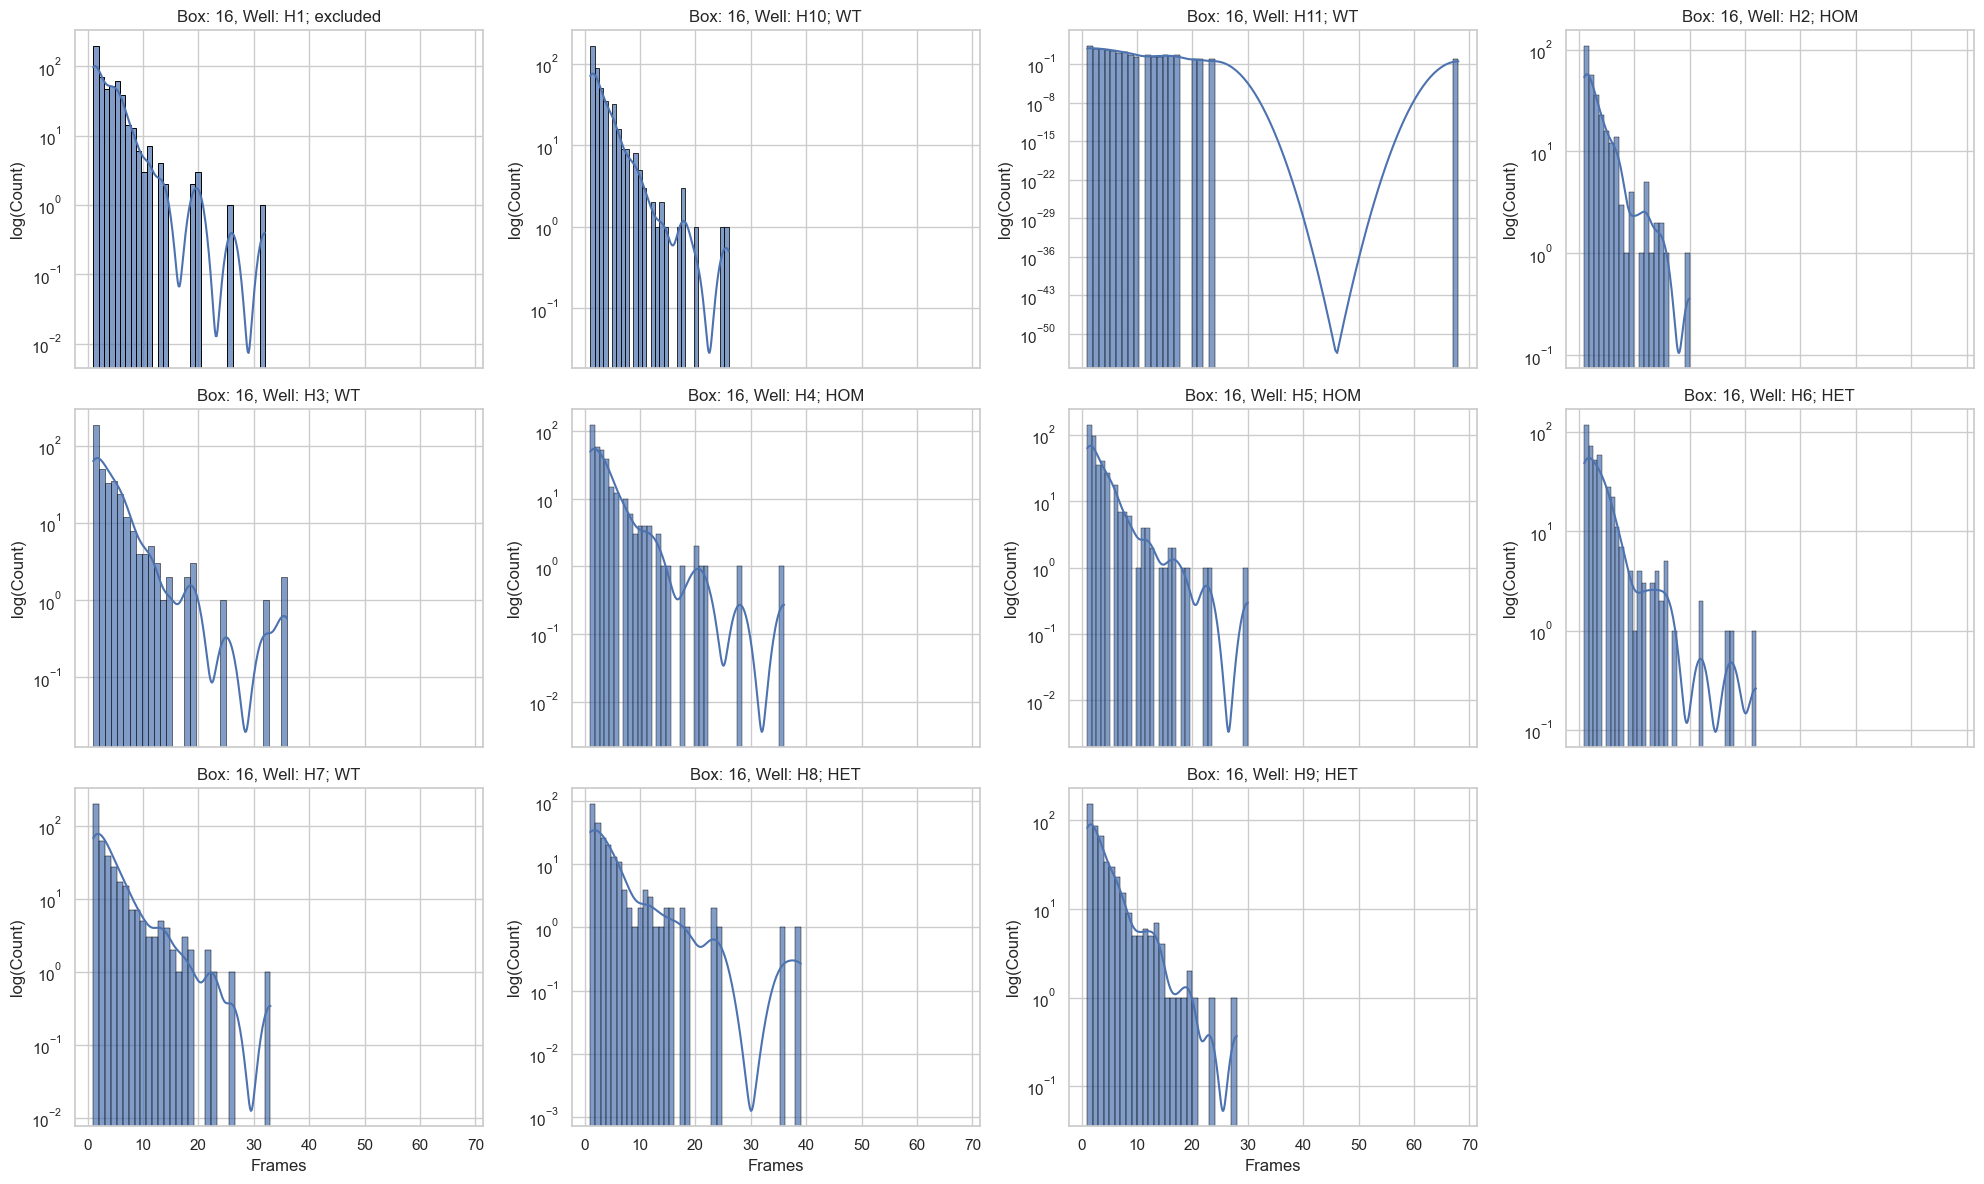

In [81]:
all_10mM = df_raw[df_raw["condition"] == 10]
all_10mM_grouped = list(all_10mM.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_10mM_grouped]

# Pass all fish at once
pnpo_ptz_obj_raw.plot_fish_count_hist(box_well_list=fish_list)

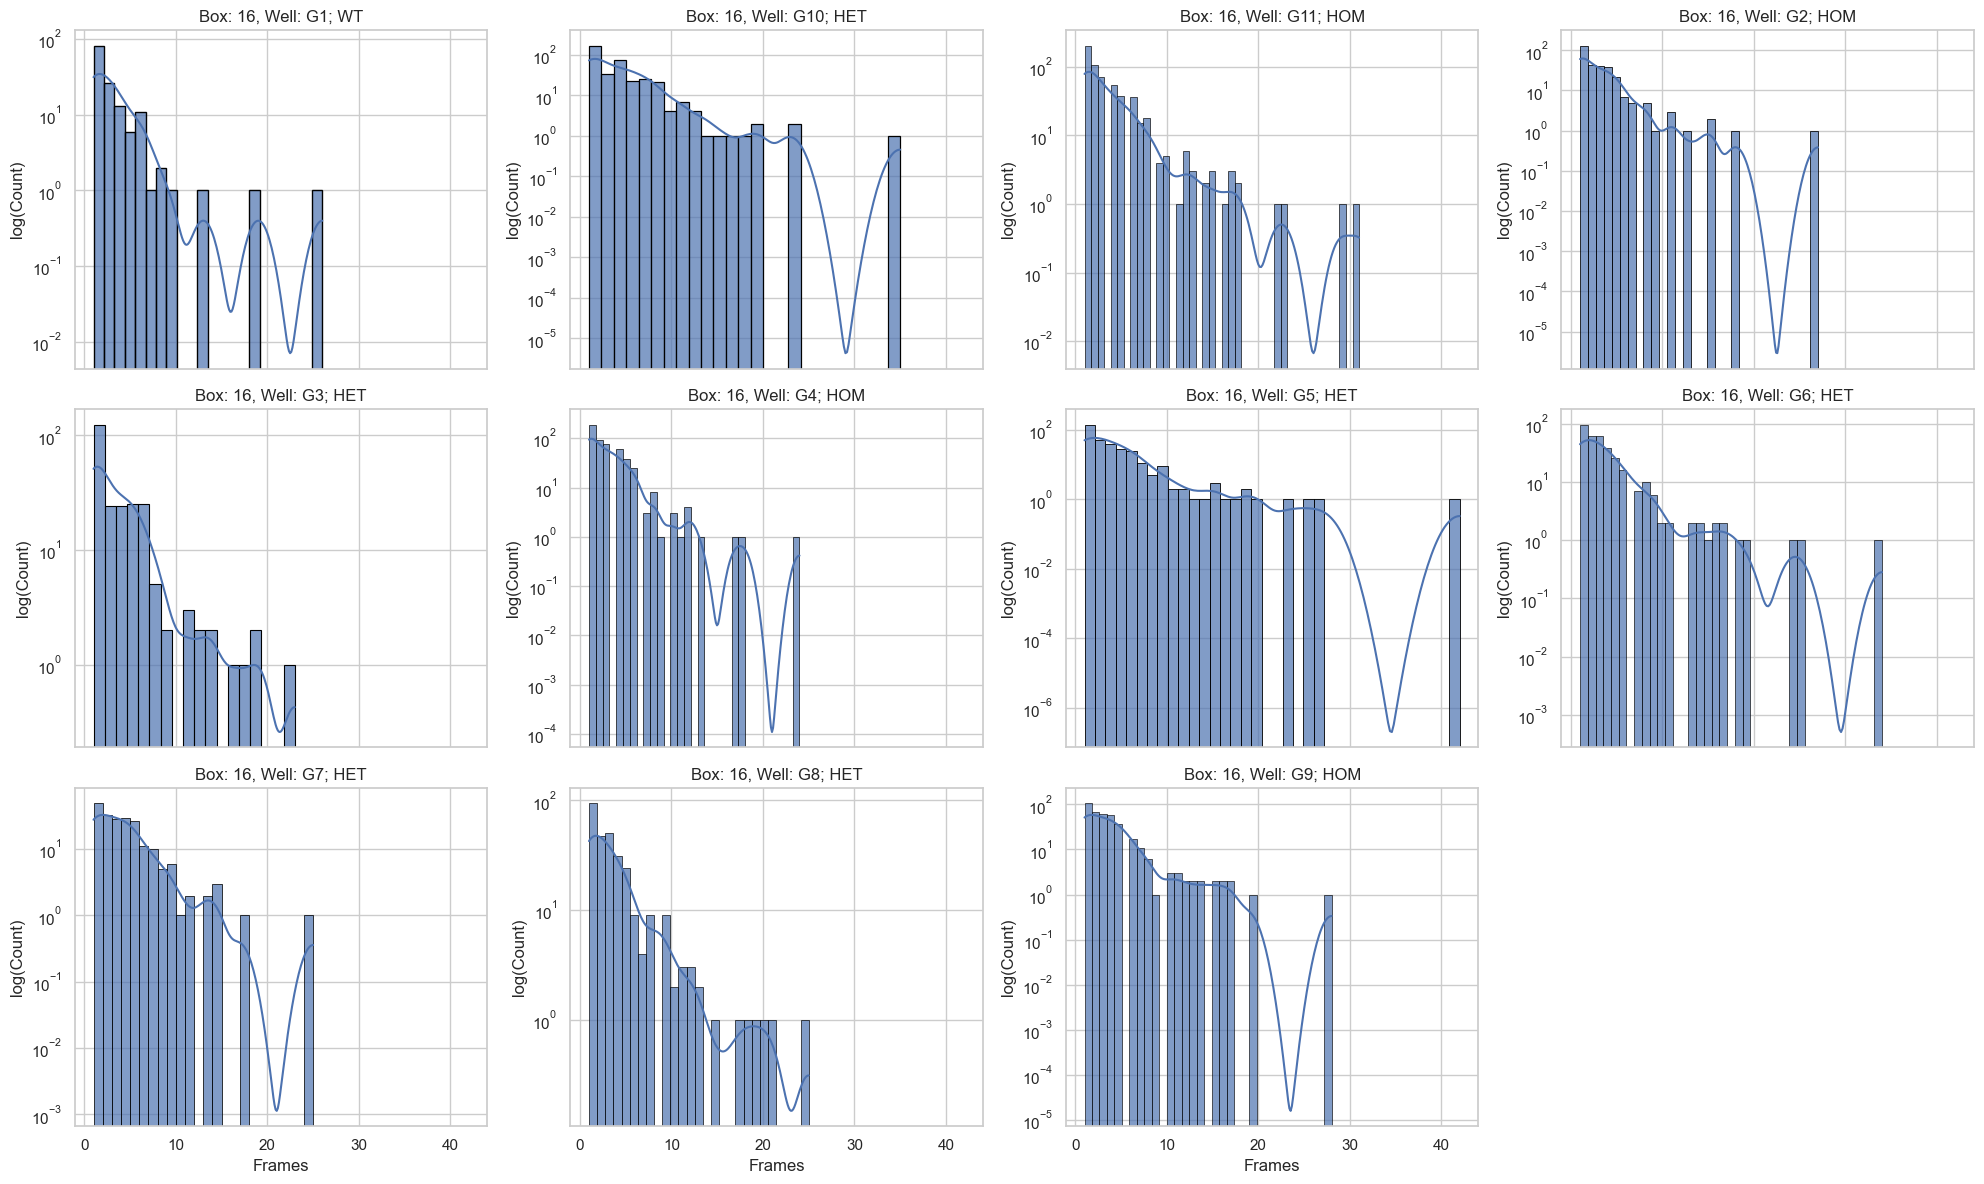

In [82]:
all_5mM = df_raw[df_raw["condition"] == 5]
all_5mM_grouped = list(all_5mM.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_5mM_grouped]

# Pass all fish at once
pnpo_ptz_obj_raw.plot_fish_count_hist(box_well_list=fish_list)

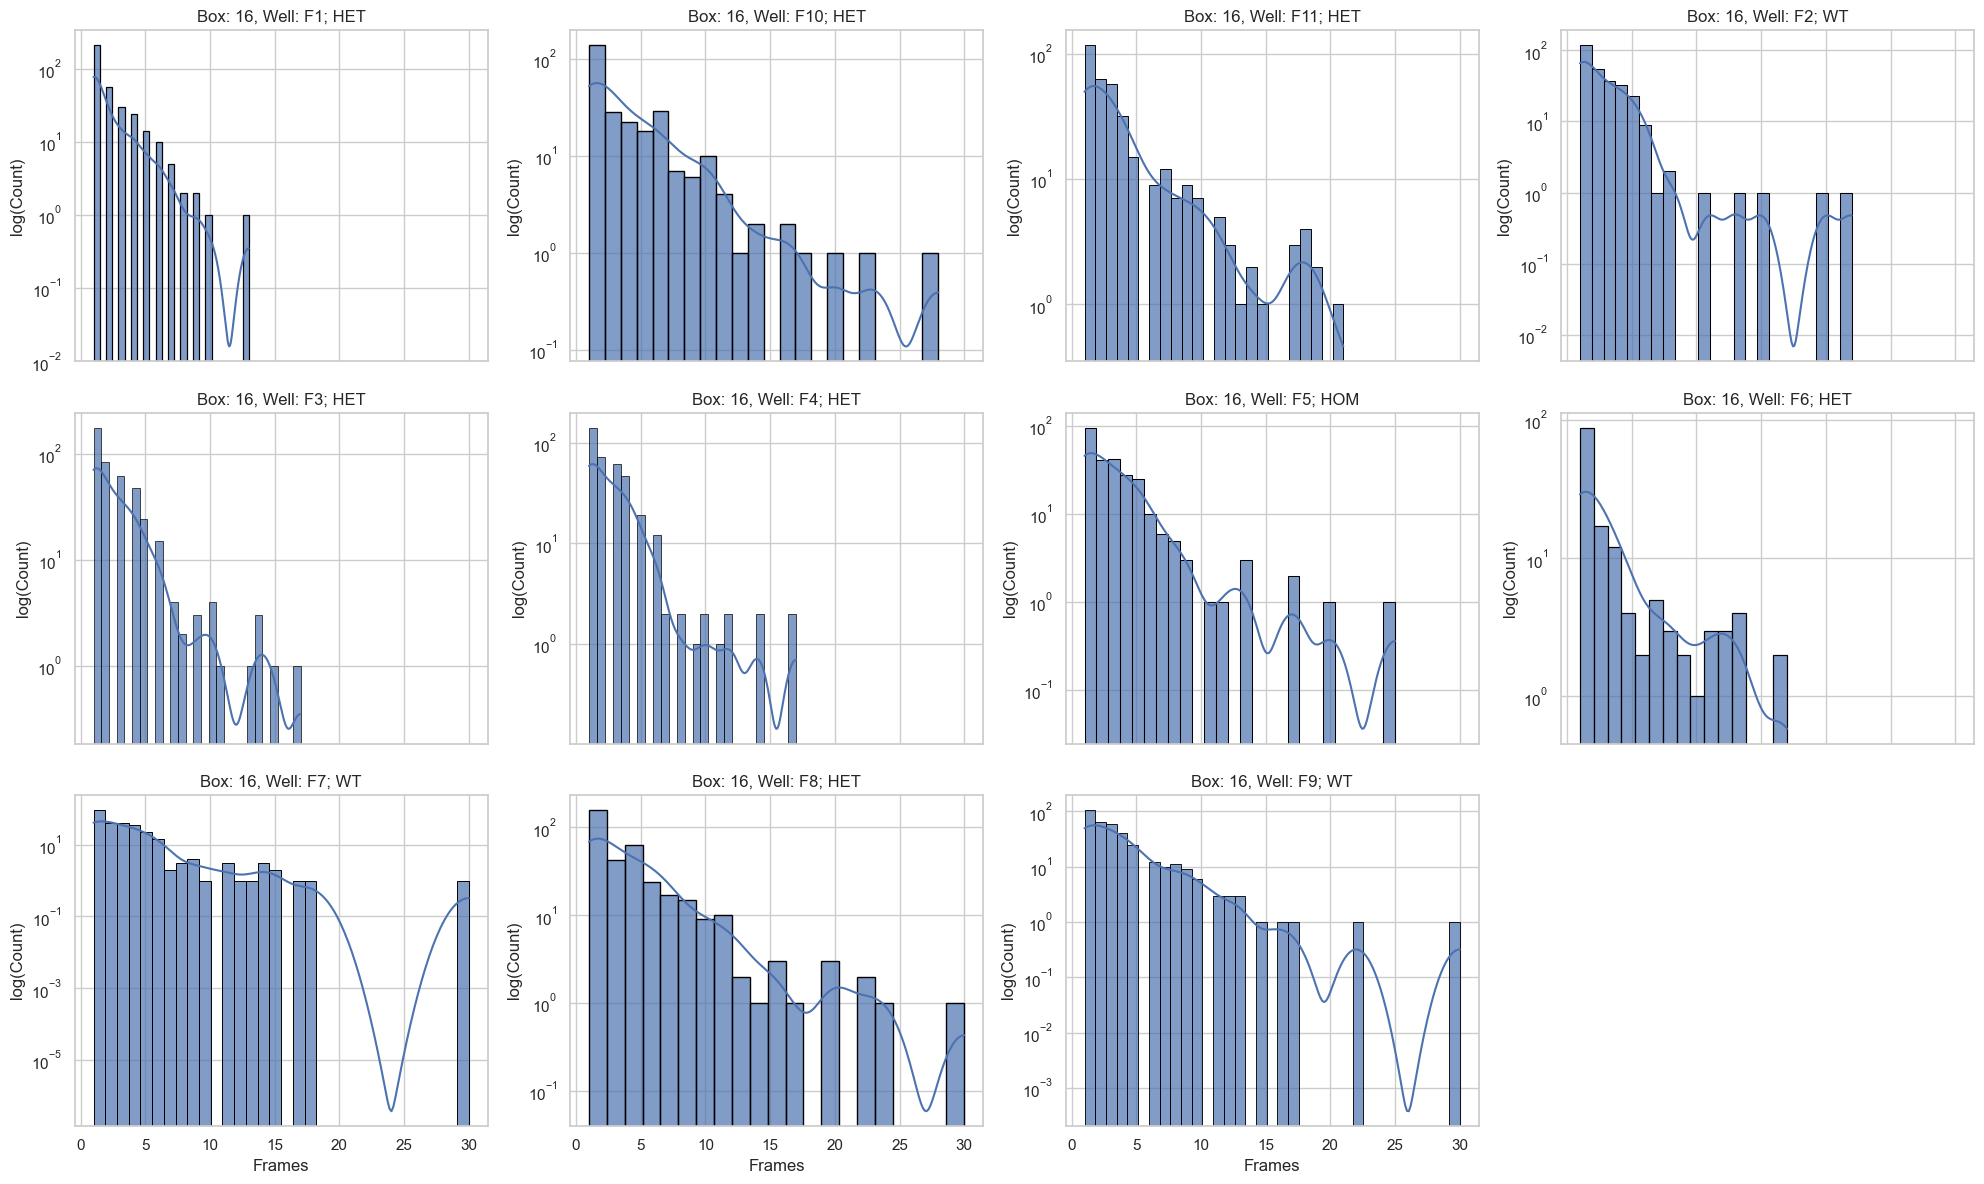

In [84]:
all_2mM = df_raw[df_raw["condition"] == 2]
all_2mM_grouped = list(all_2mM.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_2mM_grouped]

# Pass all fish at once
pnpo_ptz_obj_raw.plot_fish_count_hist(box_well_list=fish_list)

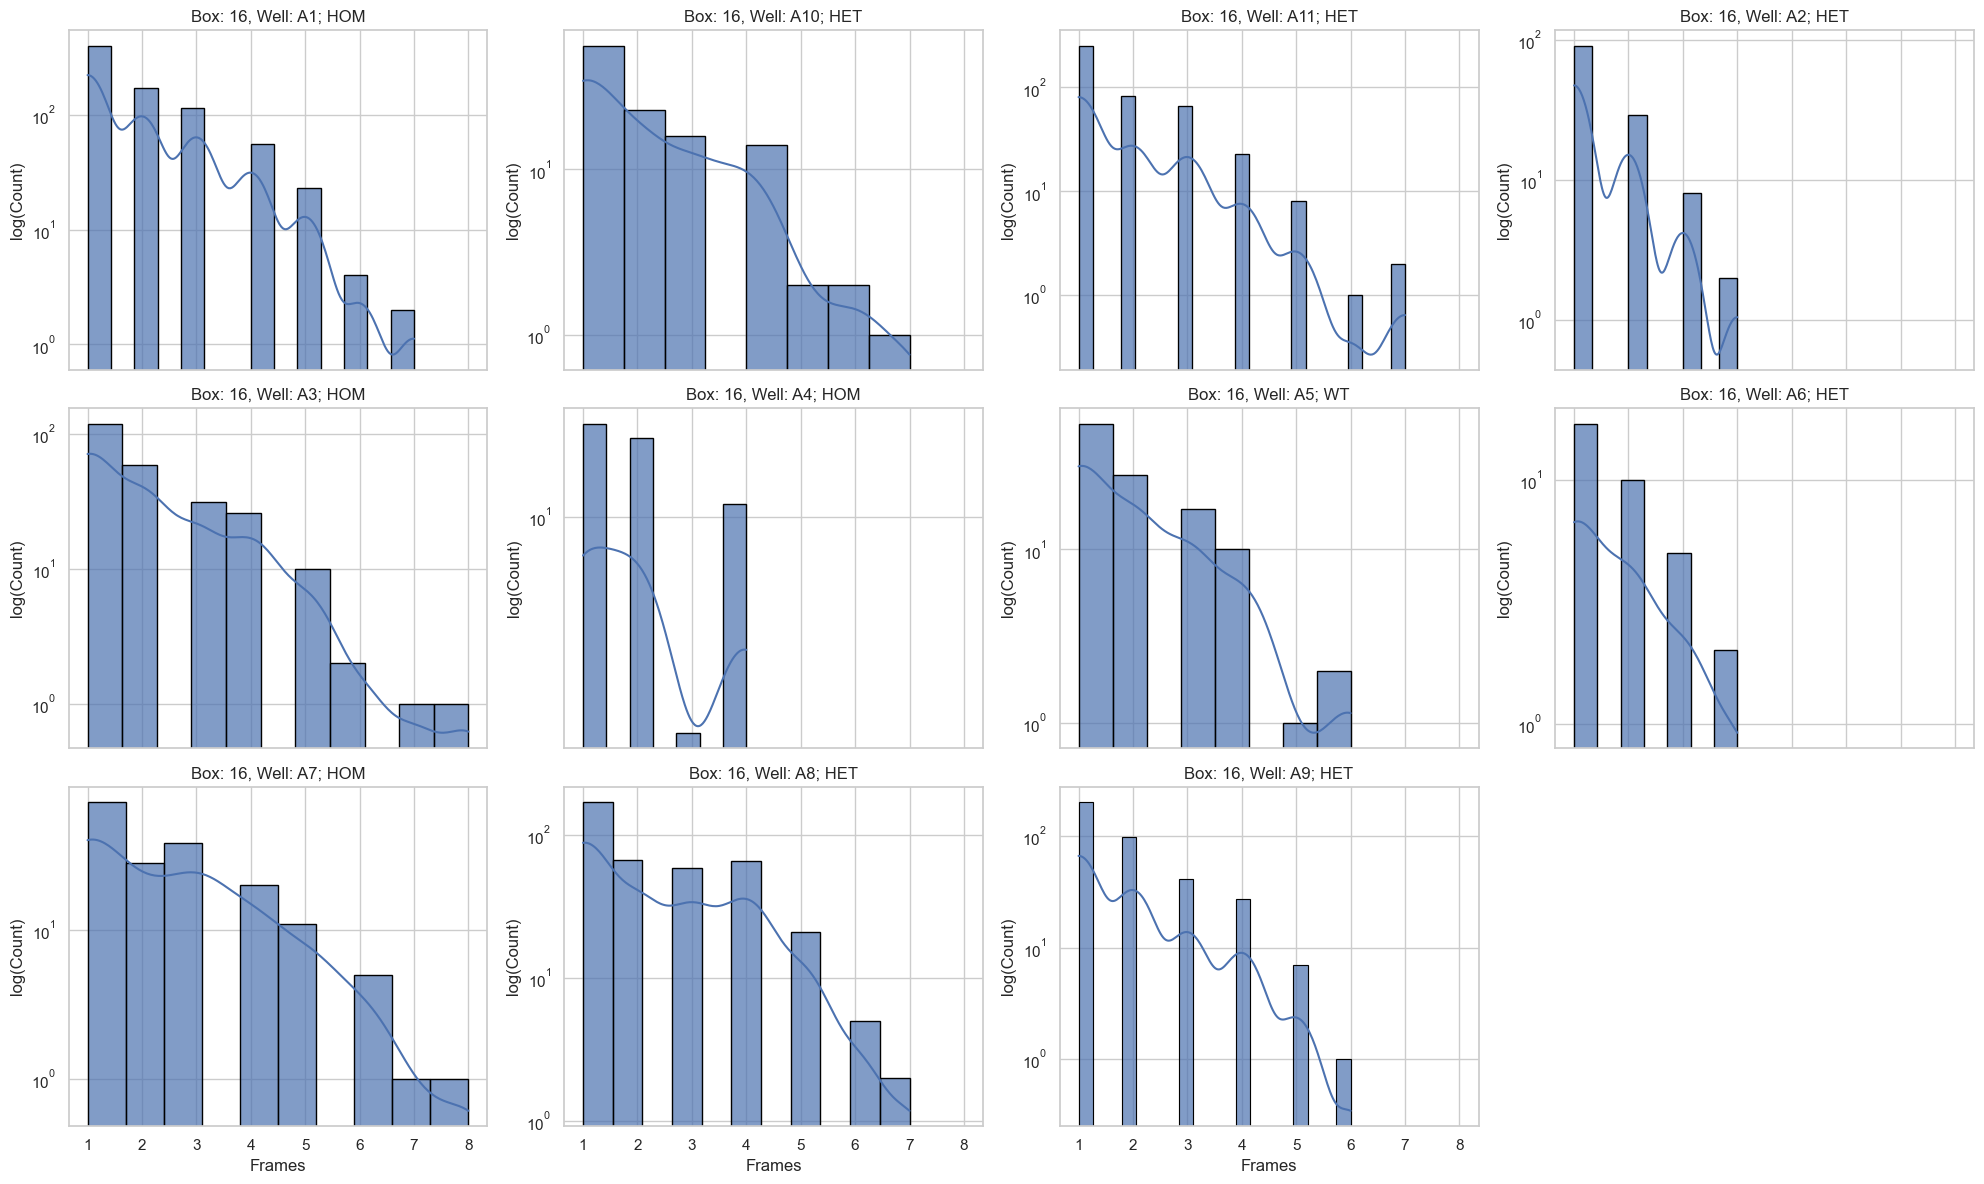

In [87]:
all_0mM = df_raw[df_raw["condition"] == 0]
all_0mM_grouped = list(all_0mM.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_0mM_grouped]

# Pass all fish at once
pnpo_ptz_obj_raw.plot_fish_count_hist(box_well_list=fish_list)

In [83]:
df_raw['condition'].unique()

array([ 0.  ,  0.5 ,  0.75,  1.  ,  1.5 ,  2.  ,  5.  , 10.  ])

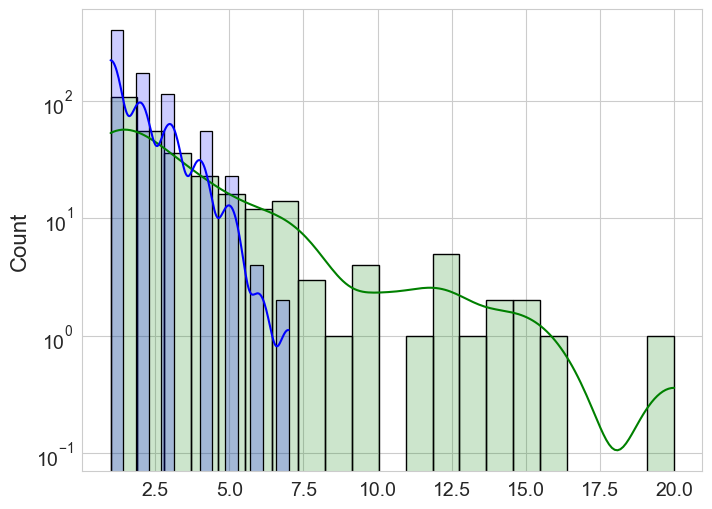

In [27]:
plt.figure(figsize=(8, 6))
    
# Plot first series
sns.histplot(fishH2_count_durations, kde=True, color="green", edgecolor="black", alpha=0.2)

# # Plot second series
sns.histplot(fishA1_count_durations, kde=True, color="blue", edgecolor="black", alpha=0.2)


plt.yscale("log")

plt.show()